# 🎯 Pipeline FPD — Hackathon TMB × PIT



---


## 1️⃣ Imports e configuração

In [ ]:
!pip install pandas numpy scikit-learn xgboost lightgbm imbalanced-learn optuna matplotlib seaborn scipy openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 12.8 MB/s eta 0:00:00


In [ ]:
# Instale o que faltar com:
#   pip install pandas numpy scikit-learn xgboost lightgbm imbalanced-learn optuna matplotlib seaborn scipy openpyxl

import pandas as pd
import numpy as np
import re
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              f1_score, precision_score, recall_score,
                              roc_curve, precision_recall_curve)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import TimeSeriesSplit

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from scipy.stats import ks_2samp

SEED = 42
np.random.seed(SEED)
pd.set_option('display.max_columns', None)
print('✅ Bibliotecas carregadas')

✅ Bibliotecas carregadas


## 2️⃣ Carregamento dos dados

In [ ]:
ARQUIVO = 'basetreinamento.xlsx'
df = pd.read_excel(ARQUIVO)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (99999, 56)


,pedido_id,CPF,SCORE_HCP4,SCORE_HCP5,SCORE_HEST,SCORE_HFI4,SCORE_HFI5,HI01_PROB,HI01_CONCEITO,SCORE_HIPA,SCORE_HIPN,HPG5,HCR5,H5OR,SCORE_HRM5,SCORE_HSV4,SCORE_HSV5,SCORE_HVA4,SCORE_HVA5,MENSAGEM_TIPO_REGISTRO,FPD,produtor,lancamento,segmento,status_cobranca,status_financeiro,status_pedido,nome,email,score,categoria_risco_score,documento,endereco_cep,endereco_estado,endereco_cidade,nascimento,idade,telefone_ativo,modalidade,total_financiado,quantidade_parcelas,saldo_vencido,quantidade_parcelas_vencidas,recebido,primeiro_vencimento_em_atraso,dias_em_atraso,pdd,saldo_vencido_com_juros,total_pago_com_juros,aguardando_pagamento_sem_juros,vencidos_sem_juros_tmb,recebido_sem_juros_tmb,data_efetivacao,data_quitacao,order_bump,pedido_pai_ob
0,26414,D6CEA19DCA,567,567,1,558,570,NaN,NaN,99,100,NaN,NaN,NaN,NaN,500,538,458,494,APTOS,NÃ£o,Produtor_1583,Lancamento_2563,Autoconhecimento,CobranÃ§a Interna,Inadimplente,Efetivado,Cliente_25AAFE70,user_6DDD6F8B@anon.local,130,Alto,D6CEA19DCA,88220000,Santa Catarina,Cidade_1893,1978-12-12 00:00:00,47,BDECE65488,Compartilhado,1944.22,13.0,743.7,5.0,1200.52,2024-11-20 00:00:00,434,False,743.7,1244.15,NaN,533.25,932.35,2024-08-21 16:48:00,NaT,NaT,NaN
1,60182,BC8B4630C6,580,567,6,679,621,0.099992,0.0,99,94,191.0,88.0,50698.0,1599.0,575,623,673,598,APTOS,NÃ£o,Produtor_0238,Lancamento_2456,Empreendedor,NaN,Adimplente,Cancelamento Solicitado,Cliente_45B91102,user_9612B4E0@anon.local,196,Alto,BC8B4630C6,39540000,MG,Cidade_3985,1981-09-14 00:00:00,44,6F2C9BC475,Compartilhado,129.7,1.0,NaN,0.0,129.70,NaN,NaN,False,NaN,129.70,NaN,NaN,97.28,2024-06-07 00:12:00,NaT,NaT,NaN
2,938745,BC8B4630C6,580,567,6,679,621,0.099992,0.0,99,94,191.0,88.0,50698.0,1599.0,575,623,673,598,APTOS,NÃ£o,Produtor_0181,Lancamento_2660,Empreendedor,NaN,Quitado,Efetivado,Cliente_CF1B01F0,user_9612B4E0@anon.local,710,Baixo,BC8B4630C6,39540-000,MG,Cidade_3985,1981-09-14 00:00:00,44,56C8E4B75C,Antecipado,1796.04,12.0,NaN,0.0,1796.04,NaN,NaN,False,NaN,1820.73,NaN,NaN,1497.00,2024-06-07 21:59:00,2025-07-17 00:15:00,NaT,NaN


## 3️⃣ Limpeza: remoção de leakage

> Regra inegociável do desafio: o modelo deve usar apenas informações disponíveis no momento do checkout.


In [ ]:
# 1) Colunas pós-evento — LEAKAGE
LEAKAGE_COLS = [
    'status_cobranca', 'status_financeiro', 'status_pedido',
    'saldo_vencido', 'quantidade_parcelas_vencidas', 'recebido',
    'primeiro_vencimento_em_atraso', 'dias_em_atraso', 'pdd',
    'saldo_vencido_com_juros', 'total_pago_com_juros',
    'aguardando_pagamento_sem_juros', 'vencidos_sem_juros_tmb',
    'recebido_sem_juros_tmb', 'data_quitacao', 'endereco_estado'
]

# 2) Identificadores / PII
ID_COLS = [
    'pedido_id', 'CPF', 'documento', 'documento2', 'nome', 'email',
    'telefone_ativo', 'endereco_cep', 'endereco_cidade', 'pedido_pai_ob',
]

cols_to_drop = [c for c in (LEAKAGE_COLS + ID_COLS) if c in df.columns]
df_clean = df.drop(columns=cols_to_drop).copy()

print(f'🗑️  Removidas {len(cols_to_drop)} colunas: {cols_to_drop}')
print(f'📉 Shape após limpeza: {df_clean.shape}')

🗑️  Removidas 25 colunas: ['status_cobranca', 'status_financeiro', 'status_pedido', 'saldo_vencido', 'quantidade_parcelas_vencidas', 'recebido', 'primeiro_vencimento_em_atraso', 'dias_em_atraso', 'pdd', 'saldo_vencido_com_juros', 'total_pago_com_juros', 'aguardando_pagamento_sem_juros', 'vencidos_sem_juros_tmb', 'recebido_sem_juros_tmb', 'data_quitacao', 'endereco_estado', 'pedido_id', 'CPF', 'documento', 'nome', 'email', 'telefone_ativo', 'endereco_cep', 'endereco_cidade', 'pedido_pai_ob']
📉 Shape após limpeza: (99999, 31)


## 4️⃣ Target FPD

In [ ]:
def map_fpd(v):
    s = str(v).strip().lower()
    if 'sim' in s or s == 's' or s == '1':
        return 1
    return 0

df_clean['FPD'] = df['FPD'].apply(map_fpd).astype(int)
print(df_clean['FPD'].value_counts())
print(f'Taxa positiva: {df_clean["FPD"].mean():.2%}')

FPD
0    86136
1    13863
Name: count, dtype: int64
Taxa positiva: 13.86%


## 5️⃣ Feature engineering

In [ ]:
hoje = datetime.today()

def fix_idade(v):
    if pd.isna(v): return np.nan
    if isinstance(v, (int, float)): return float(v)
    if isinstance(v, (datetime, pd.Timestamp)):
        return (hoje - v).days // 365
    return np.nan

df_clean['idade'] = df_clean['idade'].apply(fix_idade)
df_clean['idade'] = pd.to_numeric(df_clean['idade'], errors='coerce')

if 'nascimento' in df_clean.columns:
    nasc = pd.to_datetime(df_clean['nascimento'], errors='coerce')
    df_clean['idade'] = df_clean['idade'].fillna((hoje - nasc).dt.days // 365)
    df_clean = df_clean.drop(columns=['nascimento'])

df_clean['idade'] = pd.to_numeric(df_clean['idade'], errors='coerce')

df_clean['data_efetivacao'] = pd.to_datetime(df_clean['data_efetivacao'], errors='coerce')
df_clean['hora_compra'] = df_clean['data_efetivacao'].dt.hour

def periodo_do_dia(h):
    if pd.isna(h): return 'desconhecido'
    if 0 <= h < 6:   return 'madrugada'
    if 6 <= h < 12:  return 'manha'
    if 12 <= h < 18: return 'tarde'
    return 'noite'

df_clean['periodo_compra'] = df_clean['hora_compra'].apply(periodo_do_dia)
df_clean['compra_noturna'] = ((df_clean['hora_compra'] >= 22) |
                               (df_clean['hora_compra'] < 6)).astype(int)
df_clean['data_efetivacao'] = df_clean['data_efetivacao'].dt.normalize()

for c in ['total_financiado', 'quantidade_parcelas', 'score']:
    if c in df_clean.columns:
        df_clean[c] = pd.to_numeric(df_clean[c], errors='coerce')

if (
    'total_financiado' in df_clean.columns and
    'quantidade_parcelas' in df_clean.columns
):

    df_clean['valor_parcela'] = (
        df_clean['total_financiado'] /
        df_clean['quantidade_parcelas'].replace(0, np.nan)
    )

if 'total_financiado' in df_clean.columns:

    df_clean['log_total_financiado'] = np.log1p(
        df_clean['total_financiado']
    )

if (
    'score' in df_clean.columns and
    'quantidade_parcelas' in df_clean.columns
):

    df_clean['score_x_parcelas'] = (
        df_clean['score'] *
        df_clean['quantidade_parcelas']
    )
if (
    'score' in df_clean.columns and
    'total_financiado' in df_clean.columns
):

    df_clean['score_por_valor'] = (
        df_clean['score'] /
        (df_clean['total_financiado'] + 1)
    )
if 'categoria_risco_score' in df_clean.columns:
    df_clean = df_clean.drop(columns=['categoria_risco_score'])

for col in ['produtor', 'lancamento']:

    if col in df_clean.columns:

        freq = df_clean[col].value_counts(normalize=True)

        df_clean[col + '_freq'] = df_clean[col].map(freq)

        df_clean = df_clean.drop(columns=[col])

df_clean.columns = [re.sub(r'[^\w]', '_', c) for c in df_clean.columns]

obj_cols = df_clean.select_dtypes(include='object').columns.tolist()
if obj_cols:
    print(f'⚠️  Removendo objects não tratados: {obj_cols}')
    df_clean = df_clean.drop(columns=obj_cols)

print(f'✅ Shape final: {df_clean.shape}')
print(f'NaT em data_efetivacao: {df_clean["data_efetivacao"].isna().sum()}')

⚠️  Removendo objects não tratados: ['MENSAGEM_TIPO_REGISTRO', 'segmento', 'modalidade', 'periodo_compra']
✅ Shape final: (99999, 32)
NaT em data_efetivacao: 0


## 6️⃣ Split TEMPORAL




In [ ]:
df_clean = df_clean.dropna(subset=['data_efetivacao']).reset_index(drop=True)
df_clean = df_clean.sort_values('data_efetivacao').reset_index(drop=True)
corte = int(len(df_clean) * 0.8)

print(f'📅 Treino: {df_clean["data_efetivacao"].iloc[:corte].min()} → {df_clean["data_efetivacao"].iloc[:corte].max()}')
print(f'📅 Teste:  {df_clean["data_efetivacao"].iloc[corte:].min()} → {df_clean["data_efetivacao"].iloc[corte:].max()}')

train_df = df_clean.iloc[:corte].drop(columns=['data_efetivacao'])
test_df  = df_clean.iloc[corte:].drop(columns=['data_efetivacao'])

for col in ['produtor', 'lancamento']:

    if col in train_df.columns:

        freq_map = (
            train_df[col]
            .value_counts(normalize=True)
        )

        train_df[col + '_freq'] = (
            train_df[col]
            .map(freq_map)
        )

        test_df[col + '_freq'] = (
            test_df[col]
            .map(freq_map)
            .fillna(0)
        )

        train_df.drop(columns=[col], inplace=True)
        test_df.drop(columns=[col], inplace=True)


y_train = train_df['FPD'].astype(int); X_train = train_df.drop(columns=['FPD'])
y_test  = test_df['FPD'].astype(int);  X_test  = test_df.drop(columns=['FPD'])

# Ensure X_train and X_test contain only numeric columns before imputation
X_train = X_train.select_dtypes(include=np.number)
X_test = X_test.select_dtypes(include=np.number)

imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test  = pd.DataFrame(imputer.transform(X_test),  columns=X_test.columns)

print(f'\nX_train: {X_train.shape}, taxa FPD: {y_train.mean():.2%}')
print(f'X_test:  {X_test.shape}, taxa FPD: {y_test.mean():.2%}')

📅 Treino: 1970-01-01 00:00:00 → 2024-01-25 00:00:00
📅 Teste:  2024-01-25 00:00:00 → 2025-07-31 00:00:00

X_train: (79999, 29), taxa FPD: 14.33%
X_test:  (20000, 29), taxa FPD: 11.98%


## 7️⃣ Funções de avaliação



In [ ]:
def ks_statistic(y_true, y_proba):
    return ks_2samp(y_proba[y_true == 1], y_proba[y_true == 0]).statistic

def top_q_recall(y_true, y_proba, q=0.10):
    n_top = max(int(len(y_proba) * q), 1)
    idx_top = np.argsort(-y_proba)[:n_top]
    return y_true.iloc[idx_top].sum() / max(y_true.sum(), 1)

def evaluate_model(model, X_te, y_te, threshold=0.5):
    proba = model.predict_proba(X_te)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {
        'ROC_AUC': roc_auc_score(y_te, proba),
        'PR_AUC':  average_precision_score(y_te, proba),
        'KS':      ks_statistic(y_te.values, proba),
        'F1':      f1_score(y_te, pred),
        'Precision': precision_score(y_te, pred, zero_division=0),
        'Recall':  recall_score(y_te, pred),
        'Top10%':  top_q_recall(y_te, proba, 0.10),
        'Top20%':  top_q_recall(y_te, proba, 0.20),
    }

## 8️⃣ Estratégias de balanceamento



In [ ]:
def get_resampled(strategy, X, y, seed=SEED):
    if strategy in ('baseline', 'class_weight'):
        return X, y
    if strategy == 'SMOTE':
        return SMOTE(random_state=seed, k_neighbors=5).fit_resample(X, y)
    if strategy == 'UnderSample':
        return RandomUnderSampler(random_state=seed).fit_resample(X, y)
    raise ValueError(strategy)

STRATEGIES = ['class_weight', 'SMOTE', 'UnderSample']
print('Estratégias:', STRATEGIES)

Estratégias: ['class_weight', 'SMOTE', 'UnderSample']


## 9️⃣ Configuração dos modelos

In [ ]:
def build_models(use_class_weight=False):
    scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    return {
        'LogReg':       LogisticRegression(max_iter=2000, random_state=SEED, n_jobs=-1,
                                          class_weight='balanced' if use_class_weight else None),
        'XGBoost':      XGBClassifier(n_estimators=300, random_state=SEED, n_jobs=-1,
                                      use_label_encoder=False, eval_metric='auc',
                                      scale_pos_weight=scale_pos_weight if use_class_weight else 1),
        'LightGBM':     LGBMClassifier(n_estimators=300, random_state=SEED, n_jobs=-1, verbose=-1,
                                       class_weight='balanced' if use_class_weight else None),
    }

print('Modelos:', list(build_models().keys()))

Modelos: ['LogReg', 'XGBoost', 'LightGBM']


## 🔟 Grid de experimentos:



In [ ]:
scaler_global = StandardScaler()
X_train_sc = pd.DataFrame(scaler_global.fit_transform(X_train), columns=X_train.columns)
X_test_sc  = pd.DataFrame(scaler_global.transform(X_test),  columns=X_test.columns)

results = []

for strat in STRATEGIES:
    use_cw = (strat == 'class_weight')
    X_tr_r, y_tr_r = get_resampled(strat, X_train, y_train)

    print(f'\n--- {strat} | n={len(X_tr_r)} | pos={int((y_tr_r==1).sum())} ---')

    for mname, model in build_models(use_class_weight=use_cw).items():
        try:
            if mname == 'LogReg':
                if strat in ( 'class_weight'):
                    X_tr_use, X_te_use = X_train_sc, X_test_sc
                    y_tr_use = y_train
                else:
                    sc = StandardScaler()
                    X_tr_use = pd.DataFrame(sc.fit_transform(X_tr_r), columns=X_tr_r.columns)
                    X_te_use = pd.DataFrame(sc.transform(X_test), columns=X_test.columns)
                    y_tr_use = y_tr_r
                model.fit(X_tr_use, y_tr_use)
                metrics = evaluate_model(model, X_te_use, y_test)
            else:
                model.fit(X_tr_r, y_tr_r)
                metrics = evaluate_model(model, X_test, y_test)

            results.append({'modelo': mname, 'balanceamento': strat, **metrics})
            print(f'  {mname:14s} ROC={metrics["ROC_AUC"]:.3f}  KS={metrics["KS"]:.3f}  F1={metrics["F1"]:.3f}  Top10%={metrics["Top10%"]:.3f}')
        except Exception as e:
            print(f'  {mname:14s} FALHOU: {e}')

df_results = pd.DataFrame(results).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
df_results.round(4)


--- class_weight | n=79999 | pos=11466 ---
  LogReg         ROC=0.774  KS=0.410  F1=0.354  Top10%=0.284
  XGBoost        ROC=0.770  KS=0.404  F1=0.365  Top10%=0.292
  LightGBM       ROC=0.793  KS=0.444  F1=0.383  Top10%=0.308

--- SMOTE | n=137066 | pos=68533 ---
  LogReg         ROC=0.775  KS=0.413  F1=0.353  Top10%=0.280
  XGBoost        ROC=0.767  KS=0.398  F1=0.194  Top10%=0.280
  LightGBM       ROC=0.788  KS=0.438  F1=0.145  Top10%=0.298

--- UnderSample | n=22932 | pos=11466 ---
  LogReg         ROC=0.774  KS=0.413  F1=0.355  Top10%=0.282
  XGBoost        ROC=0.770  KS=0.409  F1=0.358  Top10%=0.285
  LightGBM       ROC=0.785  KS=0.425  F1=0.367  Top10%=0.291


,modelo,balanceamento,ROC_AUC,PR_AUC,KS,F1,Precision,Recall,Top10%,Top20%
0,LightGBM,class_weight,0.7929,0.3183,0.4441,0.3834,0.2710,0.6550,0.3079,0.5215
1,LightGBM,SMOTE,0.7879,0.3078,0.4380,0.1451,0.4217,0.0876,0.2979,0.5052
2,LightGBM,UnderSample,0.7849,0.3008,0.4251,0.3665,0.2463,0.7159,0.2908,0.5098
3,LogReg,SMOTE,0.7751,0.2833,0.4134,0.3534,0.2323,0.7380,0.2804,0.4856
4,LogReg,UnderSample,0.7744,0.2817,0.4126,0.3555,0.2335,0.7443,0.2824,0.4789
5,LogReg,class_weight,0.7742,0.2825,0.4100,0.3539,0.2323,0.7430,0.2837,0.4798
6,XGBoost,UnderSample,0.7704,0.2848,0.4094,0.3584,0.2457,0.6621,0.2854,0.4743
7,XGBoost,class_weight,0.7700,0.2928,0.4037,0.3652,0.2997,0.4673,0.2916,0.4885
8,XGBoost,SMOTE,0.7668,0.2800,0.3984,0.1943,0.3511,0.1343,0.2799,0.4752


## 1️⃣1️⃣ Visualização comparativa

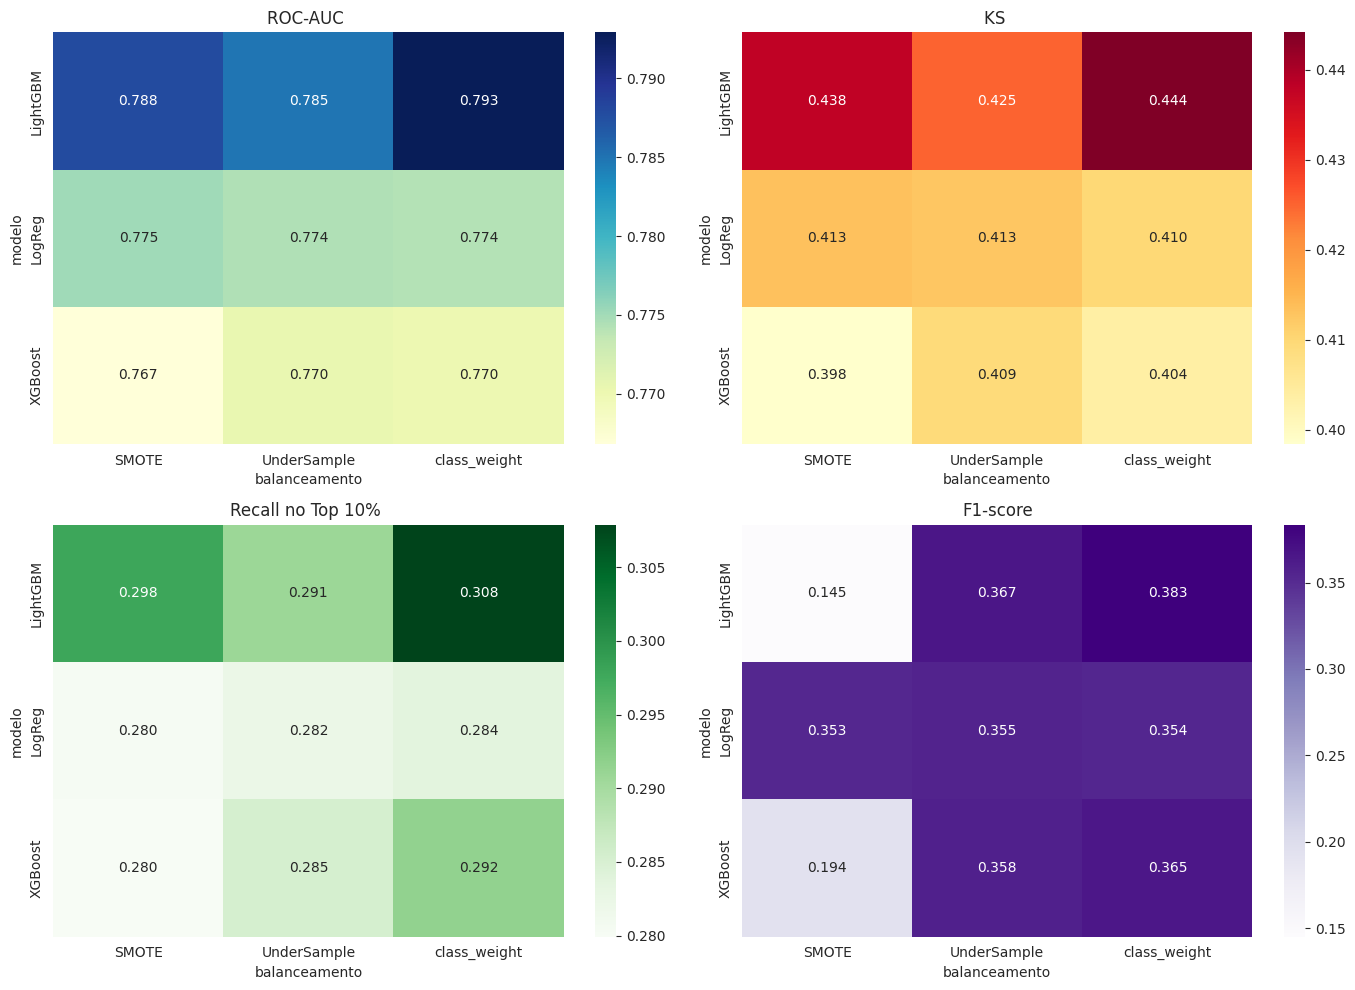

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

pivot_roc = df_results.pivot(index='modelo', columns='balanceamento', values='ROC_AUC')
sns.heatmap(pivot_roc, annot=True, fmt='.3f', cmap='YlGnBu', ax=axes[0,0])
axes[0,0].set_title('ROC-AUC ')

pivot_ks = df_results.pivot(index='modelo', columns='balanceamento', values='KS')
sns.heatmap(pivot_ks, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[0,1])
axes[0,1].set_title('KS ')

pivot_top = df_results.pivot(index='modelo', columns='balanceamento', values='Top10%')
sns.heatmap(pivot_top, annot=True, fmt='.3f', cmap='Greens', ax=axes[1,0])
axes[1,0].set_title('Recall no Top 10% ')

pivot_f1 = df_results.pivot(index='modelo', columns='balanceamento', values='F1')
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='Purples', ax=axes[1,1])
axes[1,1].set_title('F1-score')

plt.tight_layout()
plt.show()

## 1️⃣2️⃣ Top-3 combinações para tuning

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# ==================================================
# NORMALIZAÇÃO DAS MÉTRICAS
# ==================================================

metrics = [
    'ROC_AUC',
    'KS',
    'Top10%',
    'PR_AUC'
]

scaler = MinMaxScaler()

scaled = pd.DataFrame(
    scaler.fit_transform(df_results[metrics]),
    columns=metrics,
    index=df_results.index
)

# ==================================================
# PESOS DAS MÉTRICAS
# ==================================================

weights = {
    'ROC_AUC': 0.40,
    'KS':      0.30,
    'Top10%':  0.20,
    'PR_AUC':  0.10
}

# ==================================================
# SCORE COMBINADO
# ==================================================

df_results['score_combinado'] = (
    scaled['ROC_AUC'] * weights['ROC_AUC'] +
    scaled['KS']      * weights['KS'] +
    scaled['Top10%']  * weights['Top10%'] +
    scaled['PR_AUC']  * weights['PR_AUC']
)

# ==================================================
# RANKING
# ==================================================

top3 = (
    df_results
    .sort_values('score_combinado', ascending=False)
)

# ==================================================
# GARANTIR DIVERSIDADE
# ==================================================

top3 = (
    top3
    .groupby('modelo')
    .head(1)
    .sort_values('score_combinado', ascending=False)
    .head(3)
)

print('🏆 TOP 3 combinações para tuning:')

display(
    top3[
        [
            'modelo',
            'balanceamento',
            'ROC_AUC',
            'PR_AUC',
            'KS',
            'F1',
            'Top10%',
            'score_combinado'
        ]
    ]
)

🏆 TOP 3 combinações para tuning:


,modelo,balanceamento,ROC_AUC,PR_AUC,KS,F1,Top10%,score_combinado
0,LightGBM,class_weight,0.792906,0.318261,0.444141,0.383394,0.307885,1.000000
3,LogReg,SMOTE,0.775113,0.283271,0.413390,0.353411,0.280350,0.237056
7,XGBoost,class_weight,0.770004,0.292789,0.403706,0.365178,0.291615,0.200625


## 1️⃣3️⃣ Otimização de hiperparâmetros com Optuna



In [ ]:
def cv_score(params, model_name, strat, X, y, n_splits=3):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    scores = []
    for tr_idx, va_idx in tscv.split(X, y):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        X_tr_r, y_tr_r = get_resampled(strat, X_tr, y_tr)
        use_cw = (strat == 'class_weight')

        if model_name == 'XGBoost':
            spw = (y_tr==0).sum() / max((y_tr==1).sum(), 1)
            m = XGBClassifier(**params, random_state=SEED, n_jobs=-1,
                              use_label_encoder=False, eval_metric='auc',
                              scale_pos_weight=spw if use_cw else 1)
        elif model_name == 'LightGBM':
            m = LGBMClassifier(**params, random_state=SEED, n_jobs=-1, verbose=-1,
                               class_weight='balanced' if use_cw else None)
        elif model_name == 'LogReg':
            sc = StandardScaler()
            X_tr_r = pd.DataFrame(sc.fit_transform(X_tr_r), columns=X_tr_r.columns)
            X_va = pd.DataFrame(sc.transform(X_va), columns=X_va.columns)
            m = LogisticRegression(**params, max_iter=3000, random_state=SEED, n_jobs=-1,
                                   class_weight='balanced' if use_cw else None)

        m.fit(X_tr_r, y_tr_r)
        scores.append(roc_auc_score(y_va, m.predict_proba(X_va)[:, 1]))
    return np.mean(scores)

def make_objective(model_name, strat, X, y):
    def objective(trial):
        if model_name == 'XGBoost':
            params = dict(
                n_estimators=trial.suggest_int('n_estimators', 50, 250),
                max_depth=trial.suggest_int('max_depth', 3, 10),
                learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                subsample=trial.suggest_float('subsample', 0.6, 1.0),
                colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
                reg_alpha=trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
                reg_lambda=trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
                min_child_weight=trial.suggest_int('min_child_weight', 1, 20),
            )
        elif model_name == 'LightGBM':
            params = dict(
                n_estimators=trial.suggest_int('n_estimators', 50, 200),
                num_leaves=trial.suggest_int('num_leaves', 15, 200),
                max_depth=trial.suggest_int('max_depth', 3, 12),
                learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                subsample=trial.suggest_float('subsample', 0.6, 1.0),
                colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
                reg_alpha=trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
                reg_lambda=trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
                min_child_samples=trial.suggest_int('min_child_samples', 5, 100),
            )
        elif model_name == 'LogReg':
            params = dict(
                C=trial.suggest_float('C', 1e-3, 100, log=True),
                penalty=trial.suggest_categorical('penalty', ['l1','l2']),
                solver='liblinear',
            )
        return cv_score(params, model_name, strat, X, y)
    return objective

tuning_results = []
best_models = {}
N_TRIALS = 5

for i, row in top3.iterrows():
    mname, strat = row['modelo'], row['balanceamento']
    print(f'\n=== TUNING {i+1}/3: {mname} + {strat} ===')
    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(make_objective(mname, strat, X_train, y_train),
                   n_trials=N_TRIALS, show_progress_bar=False)

    best_params = study.best_params
    print(f'  CV ROC-AUC: {study.best_value:.4f}')
    print(f'  params: {best_params}')

    X_tr_r, y_tr_r = get_resampled(strat, X_train, y_train)
    use_cw = (strat == 'class_weight')

    if mname == 'XGBoost':
        spw = (y_train==0).sum() / max((y_train==1).sum(), 1)
        final = XGBClassifier(**best_params, random_state=SEED, n_jobs=-1,
                              use_label_encoder=False, eval_metric='auc',
                              scale_pos_weight=spw if use_cw else 1)
    elif mname == 'LightGBM':
        final = LGBMClassifier(**best_params, random_state=SEED, n_jobs=-1, verbose=-1,
                               class_weight='balanced' if use_cw else None)
    elif mname == 'LogReg':
        sc_final = StandardScaler()
        X_tr_r = pd.DataFrame(sc_final.fit_transform(X_tr_r), columns=X_tr_r.columns)
        X_te_use = pd.DataFrame(sc_final.transform(X_test), columns=X_test.columns)
        final = LogisticRegression(
            C=best_params['C'],
            penalty=best_params['penalty'],
            solver='liblinear', # Explicitly set solver to 'liblinear'
            max_iter=3000, random_state=SEED, n_jobs=-1,
            class_weight='balanced' if use_cw else None
        )

    if mname == 'LogReg':
        final.fit(X_tr_r, y_tr_r)
        metrics_final = evaluate_model(final, X_te_use, y_test)
    else:
        final.fit(X_tr_r, y_tr_r)
        metrics_final = evaluate_model(final, X_test, y_test)

    tuning_results.append({
        'modelo': mname, 'balanceamento': strat,
        'cv_best_auc': study.best_value,
        **metrics_final,
        'best_params': best_params
    })
    best_models[f'{mname}_{strat}'] = final

df_tuned = pd.DataFrame(tuning_results).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
print('\n🏆 RESULTADO PÓS-TUNING:')
df_tuned[['modelo','balanceamento','cv_best_auc','ROC_AUC','PR_AUC','KS','F1','Top10%']]


=== TUNING 1/3: LightGBM + class_weight ===
  CV ROC-AUC: 0.7924
  params: {'n_estimators': 127, 'num_leaves': 125, 'max_depth': 3, 'learning_rate': 0.07896186801026692, 'subsample': 0.6682096494749166, 'colsample_bytree': 0.6260206371941118, 'reg_alpha': 6.245139574743075, 'reg_lambda': 7.2866537374910445, 'min_child_samples': 82}

=== TUNING 4/3: LogReg + SMOTE ===
  CV ROC-AUC: 0.7709
  params: {'C': 0.0745934328572655, 'penalty': 'l1'}

=== TUNING 8/3: XGBoost + class_weight ===
  CV ROC-AUC: 0.7899
  params: {'n_estimators': 111, 'max_depth': 7, 'learning_rate': 0.04345454109729477, 'subsample': 0.7164916560792167, 'colsample_bytree': 0.8447411578889518, 'reg_alpha': 0.003613894271216527, 'reg_lambda': 0.01474275315991467, 'min_child_weight': 8}

🏆 RESULTADO PÓS-TUNING:


,modelo,balanceamento,cv_best_auc,ROC_AUC,PR_AUC,KS,F1,Top10%
0,XGBoost,class_weight,0.789909,0.799124,0.324731,0.451997,0.380009,0.315811
1,LightGBM,class_weight,0.792422,0.797036,0.320723,0.452536,0.371202,0.308302
2,LogReg,SMOTE,0.770866,0.775405,0.283995,0.415224,0.354642,0.283271


## 1️⃣4️⃣ Antes vs depois do tuning

In [ ]:
comp = top3[['modelo','balanceamento','ROC_AUC','KS','F1']].rename(
    columns={'ROC_AUC':'ROC_antes', 'KS':'KS_antes', 'F1':'F1_antes'}
).merge(
    df_tuned[['modelo','balanceamento','ROC_AUC','KS','F1']].rename(
        columns={'ROC_AUC':'ROC_depois', 'KS':'KS_depois', 'F1':'F1_depois'}
    ),
    on=['modelo','balanceamento']
)
comp['ΔROC'] = (comp['ROC_depois'] - comp['ROC_antes']).round(4)
comp['ΔKS']  = (comp['KS_depois'] - comp['KS_antes']).round(4)
comp

,modelo,balanceamento,ROC_antes,KS_antes,F1_antes,ROC_depois,KS_depois,F1_depois,ΔROC,ΔKS
0,LightGBM,class_weight,0.792906,0.444141,0.383394,0.797036,0.452536,0.371202,0.0041,0.0084
1,LogReg,SMOTE,0.775113,0.413390,0.353411,0.775405,0.415224,0.354642,0.0003,0.0018
2,XGBoost,class_weight,0.770004,0.403706,0.365178,0.799124,0.451997,0.380009,0.0291,0.0483


## 1️⃣5️⃣ Modelo campeão: análise detalhada

🏆 Campeão: XGBoost_class_weight
   ROC-AUC: 0.7991
   KS:      0.4520
   Top 10%: 31.58%


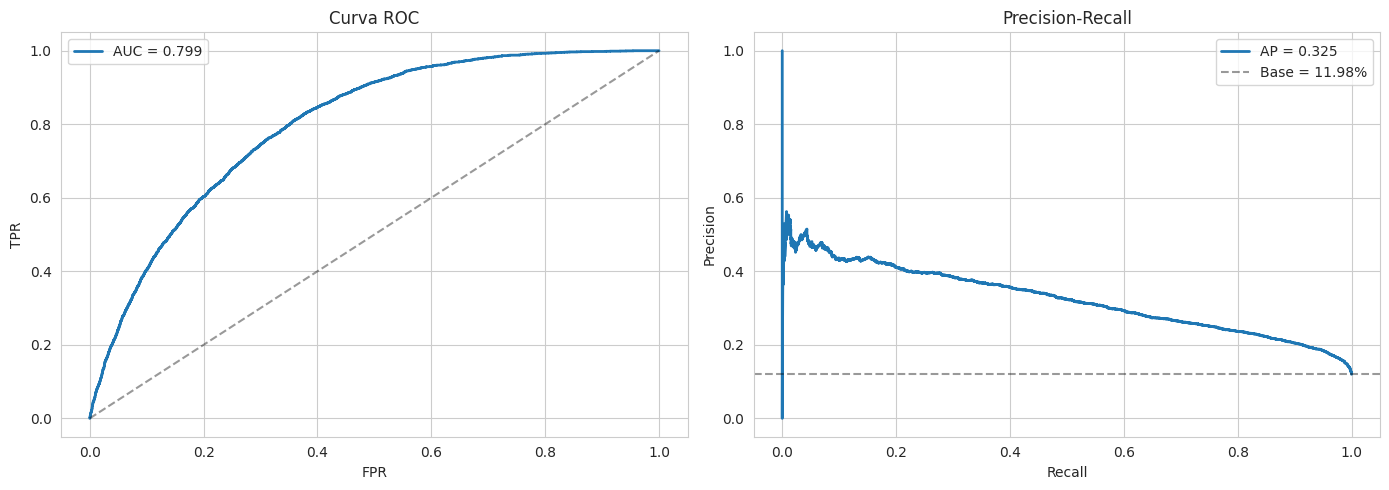

In [ ]:
champ_row = df_tuned.iloc[0]
champ_name = f'{champ_row["modelo"]}_{champ_row["balanceamento"]}'
champion = best_models[champ_name]
print(f'🏆 Campeão: {champ_name}')
print(f'   ROC-AUC: {champ_row["ROC_AUC"]:.4f}')
print(f'   KS:      {champ_row["KS"]:.4f}')
print(f'   Top 10%: {champ_row["Top10%"]:.2%}')

if champ_row['modelo'] == 'LogReg':
    sc = StandardScaler()
    X_tr_r, y_tr_r = get_resampled(champ_row['balanceamento'], X_train, y_train)
    sc.fit(X_tr_r)
    proba_test = champion.predict_proba(
        pd.DataFrame(sc.transform(X_test), columns=X_test.columns))[:, 1]
else:
    proba_test = champion.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fpr, tpr, _ = roc_curve(y_test, proba_test)
axes[0].plot(fpr, tpr, lw=2, label=f'AUC = {champ_row["ROC_AUC"]:.3f}')
axes[0].plot([0,1],[0,1], 'k--', alpha=0.4)
axes[0].set(xlabel='FPR', ylabel='TPR', title='Curva ROC')
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, proba_test)
axes[1].plot(rec, prec, lw=2, label=f'AP = {champ_row["PR_AUC"]:.3f}')
axes[1].axhline(y_test.mean(), color='k', linestyle='--', alpha=0.4,
                label=f'Base = {y_test.mean():.2%}')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall')
axes[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
# Tabela de decis (decil 1 = piores 10%)
df_decis = pd.DataFrame({'y': y_test.values, 'proba': proba_test})
df_decis['decil'] = pd.qcut(df_decis['proba'], 10, labels=False, duplicates='drop') + 1
df_decis['decil'] = 11 - df_decis['decil']

tab = df_decis.groupby('decil').agg(
    qtd=('y','size'), fpd=('y','sum'), taxa_fpd=('y','mean'),
    score_min=('proba','min'), score_max=('proba','max')
).round(4)
tab['pct_fpd_acumulado'] = (tab['fpd'].cumsum() / tab['fpd'].sum()).round(4)
tab['lift'] = (tab['taxa_fpd'] / y_test.mean()).round(2)
print('📊 Tabela de decis (decil 1 = 10% piores scores):')
tab

📊 Tabela de decis (decil 1 = 10% piores scores):


,qtd,fpd,taxa_fpd,score_min,score_max,pct_fpd_acumulado,lift
decil,,,,,,,
1,2000,757,0.3785,0.7262,0.8786,0.3158,3.16
2,2000,505,0.2525,0.6312,0.7262,0.5265,2.11
3,2000,360,0.1800,0.5383,0.6311,0.6767,1.50
4,2000,283,0.1415,0.4443,0.5383,0.7947,1.18
5,2000,209,0.1045,0.3472,0.4443,0.8819,0.87
6,2000,145,0.0725,0.2528,0.3472,0.9424,0.60
7,2000,74,0.0370,0.1656,0.2528,0.9733,0.31
8,2000,42,0.0210,0.0941,0.1655,0.9908,0.18
9,2000,17,0.0085,0.0447,0.0941,0.9979,0.07


## 1️⃣6️⃣ Faixas de risco para a política de cobrança

In [ ]:
p25 = np.percentile(proba_test, 25)
p50 = np.percentile(proba_test, 50)
p75 = np.percentile(proba_test, 75)
print(f"{p25}, {p50}, {p75}")
def classificar_faixa(p):
    if p < p25:  return 'Baixo'
    if p < p50:  return 'Medio'
    if p < p75:  return 'Alto'
    return 'Critico'

df_decis['faixa'] = df_decis['proba'].apply(classificar_faixa)
faixa_tab = df_decis.groupby('faixa').agg(
    qtd=('y','size'), fpd=('y','sum'), taxa_fpd=('y','mean')
).reindex(['Baixo','Medio','Alto','Critico']).round(4)
faixa_tab['lift'] = (faixa_tab['taxa_fpd'] / y_test.mean()).round(2)
print('Distribuição de faixas (base de teste):')
faixa_tab

0.12668322026729584, 0.34720733761787415, 0.5818880200386047
Distribuição de faixas (base de teste):


,qtd,fpd,taxa_fpd,lift
faixa,,,,
Baixo,5000,36,0.0072,0.06
Medio,5000,247,0.0494,0.41
Alto,5000,666,0.1332,1.11
Critico,5000,1448,0.2896,2.42


## 1️⃣7️⃣ Geração da submissão final

In [ ]:
df_sub = pd.read_excel('submissao.xlsx')
print(f'Submissão shape: {df_sub.shape}')

sub_pedido_id = df_sub['pedido_id'].copy()

cols_drop_sub = [c for c in (LEAKAGE_COLS + ID_COLS) if c in df_sub.columns]
df_sub_clean = df_sub.drop(columns=cols_drop_sub)

df_sub_clean['idade'] = df_sub_clean['idade'].apply(fix_idade)
if 'nascimento' in df_sub_clean.columns:
    nasc = pd.to_datetime(df_sub_clean['nascimento'], errors='coerce')
    df_sub_clean['idade'] = df_sub_clean['idade'].fillna((hoje - nasc).dt.days // 365)
    df_sub_clean = df_sub_clean.drop(columns=['nascimento'])

df_sub_clean['data_efetivacao'] = pd.to_datetime(df_sub_clean['data_efetivacao'], errors='coerce')
df_sub_clean['hora_compra'] = df_sub_clean['data_efetivacao'].dt.hour
df_sub_clean['periodo_compra'] = df_sub_clean['hora_compra'].apply(periodo_do_dia)
df_sub_clean['compra_noturna'] = ((df_sub_clean['hora_compra'] >= 22) |
                                   (df_sub_clean['hora_compra'] < 6)).astype(int)
df_sub_clean = df_sub_clean.drop(columns=['data_efetivacao'])

for c in ['total_financiado','quantidade_parcelas','score']:
    if c in df_sub_clean.columns:
        df_sub_clean[c] = pd.to_numeric(df_sub_clean[c], errors='coerce')

if 'categoria_risco_score' in df_sub_clean.columns:
    df_sub_clean = df_sub_clean.drop(columns=['categoria_risco_score'])
if 'endereco_estado' in df_sub_clean.columns:
    df_sub_clean['endereco_estado'] = df_sub_clean['endereco_estado'].astype(str).str.strip().str.upper().str[:2]

for col in ['produtor','lancamento']:
    if col in df_sub_clean.columns:
        freq = df[col].value_counts(normalize=True)
        df_sub_clean[col+'_freq'] = df_sub_clean[col].map(freq).fillna(0)
        df_sub_clean = df_sub_clean.drop(columns=[col])

cat_cols_sub = [c for c in ['segmento','modalidade','MENSAGEM_TIPO_REGISTRO',
                              'endereco_estado','order_bump'] if c in df_sub_clean.columns]
df_sub_clean = pd.get_dummies(df_sub_clean, columns=cat_cols_sub, drop_first=True, dummy_na=True)
df_sub_clean.columns = [re.sub(r'[^\w]', '_', c) for c in df_sub_clean.columns]

for col in X_train.columns:
    if col not in df_sub_clean.columns:
        df_sub_clean[col] = 0
df_sub_clean = df_sub_clean[X_train.columns]

df_sub_clean = pd.DataFrame(imputer.transform(df_sub_clean), columns=df_sub_clean.columns)

if champ_row['modelo'] == 'LogReg':
    sc_sub = StandardScaler()
    X_tr_r, _ = get_resampled(champ_row['balanceamento'], X_train, y_train)
    sc_sub.fit(X_tr_r)
    df_sub_scaled = pd.DataFrame(sc_sub.transform(df_sub_clean), columns=df_sub_clean.columns)
    proba_sub = champion.predict_proba(df_sub_scaled)[:, 1]
else:
    proba_sub = champion.predict_proba(df_sub_clean)[:, 1]

submissao = pd.DataFrame({
    'pedido_id': sub_pedido_id,
    'prob_fpd': proba_sub.round(4),
    'faixa_risco': [classificar_faixa(p) for p in proba_sub]
})
submissao.to_csv('submissao_final.csv', index=False)
print(f'✅ Submissão salva: submissao_final.csv ({len(submissao)} linhas)')
print(f'\nDistribuição de faixas:')
print(submissao['faixa_risco'].value_counts())
submissao.head(10)

Submissão shape: (23354, 56)
✅ Submissão salva: submissao_final.csv (23354 linhas)

Distribuição de faixas:
faixa_risco
Alto       12521
Medio       5908
Critico     4522
Baixo        403
Name: count, dtype: int64


,pedido_id,prob_fpd,faixa_risco
0,300988,0.5688,Alto
1,301277,0.5546,Alto
2,431885,0.7180,Critico
3,466590,0.3845,Alto
4,472357,0.6837,Critico
5,481126,0.3660,Alto
6,478489,0.4741,Alto
7,474888,0.4572,Alto
8,475601,0.5546,Alto
9,536323,0.6459,Critico


## 1️⃣8️⃣ Top features (resposta à banca)

📊 Interpretabilidade com SHAP


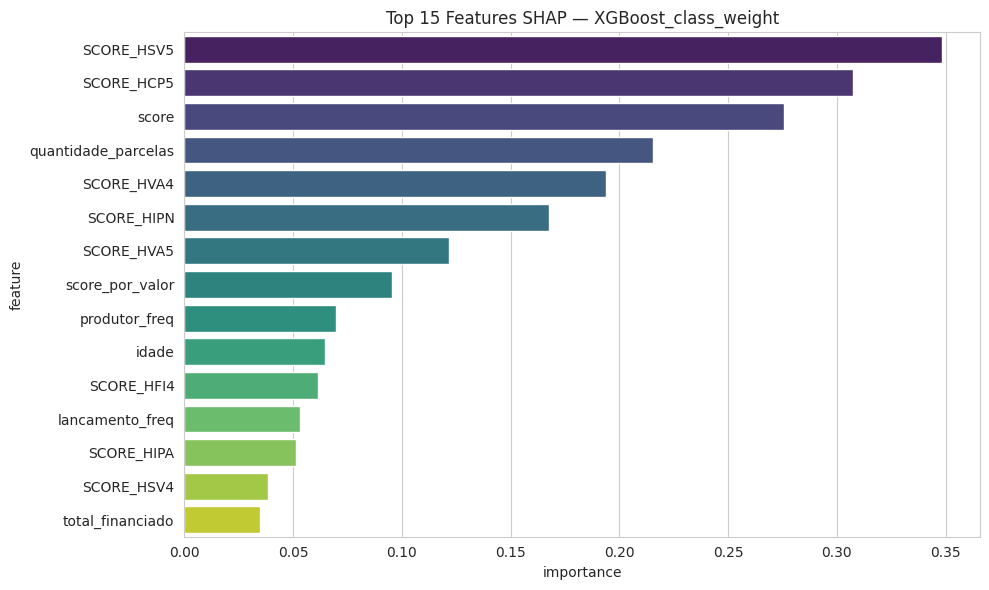

            feature  importance
         SCORE_HSV5    0.348344
         SCORE_HCP5    0.307557
              score    0.275877
quantidade_parcelas    0.215631
         SCORE_HVA4    0.193840
         SCORE_HIPN    0.167849
         SCORE_HVA5    0.121523
    score_por_valor    0.095693
      produtor_freq    0.069682
              idade    0.064559
         SCORE_HFI4    0.061564
    lancamento_freq    0.053079
         SCORE_HIPA    0.051549
         SCORE_HSV4    0.038366
   total_financiado    0.035017


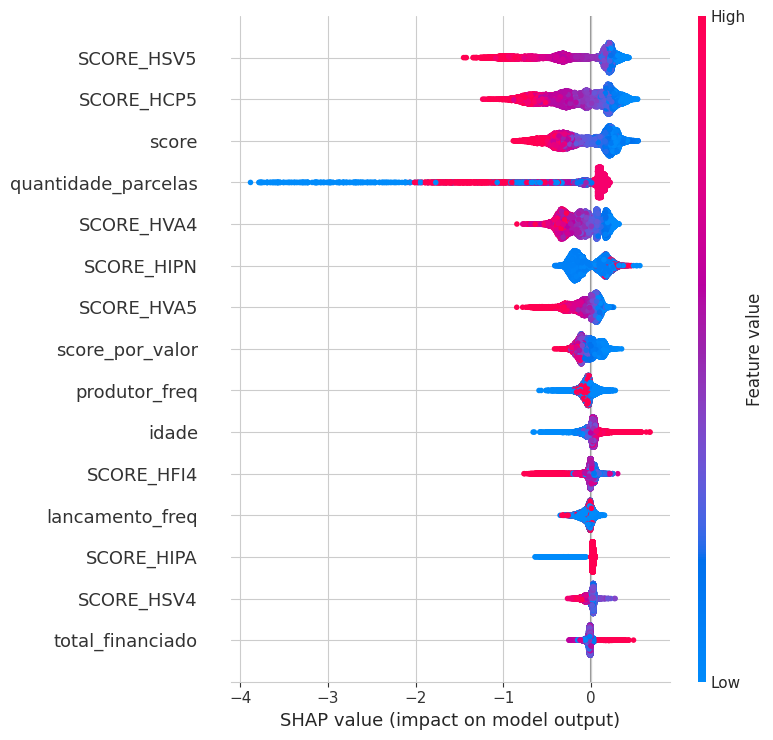

In [ ]:
# ==================================================
# INTERPRETABILIDADE DO MODELO
# ==================================================

if champ_row['modelo'] in ['LightGBM', 'XGBoost', 'RandomForest']:

    import shap

    print('📊 Interpretabilidade com SHAP')

    # ==================================================
    # SHAP VALUES
    # ==================================================

    explainer = shap.TreeExplainer(champion)

    shap_values = explainer.shap_values(X_test)

    # Compatibilidade binária
    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    # ==================================================
    # IMPORTÂNCIA MÉDIA ABSOLUTA
    # ==================================================

    mean_shap = np.abs(shap_values).mean(axis=0)

    feat_imp = pd.DataFrame({
        'feature': X_test.columns,
        'importance': mean_shap
    }).sort_values('importance', ascending=False).head(15)

    # ==================================================
    # PLOT
    # ==================================================

    plt.figure(figsize=(10,6))

    sns.barplot(
        data=feat_imp,
        x='importance',
        y='feature',
        palette='viridis'
    )

    plt.title(f'Top 15 Features SHAP — {champ_name}')

    plt.tight_layout()

    plt.show()

    print(feat_imp.to_string(index=False))

    # ==================================================
    # SHAP SUMMARY
    # ==================================================

    shap.summary_plot(
        shap_values,
        X_test,
        max_display=15
    )

# ==================================================
# LOGISTIC REGRESSION
# ==================================================

elif hasattr(champion, 'coef_'):

    feat_imp = pd.DataFrame({
        'feature': X_train.columns,
        'coef': champion.coef_[0]
    })

    feat_imp['abs_coef'] = feat_imp['coef'].abs()

    feat_imp = feat_imp.sort_values(
        'abs_coef',
        ascending=False
    ).head(15)

    # ==================================================
    # DIREÇÃO DO RISCO
    # ==================================================

    feat_imp['impacto'] = feat_imp['coef'].apply(
        lambda x: '↑ aumenta risco' if x > 0 else '↓ reduz risco'
    )

    print('\n📊 Top features da Regressão Logística:\n')

    print(
        feat_imp[
            ['feature', 'coef', 'impacto']
        ].to_string(index=False)
    )

    # ==================================================
    # PLOT
    # ==================================================

    plt.figure(figsize=(10,6))

    sns.barplot(
        data=feat_imp,
        x='coef',
        y='feature',
        palette='coolwarm'
    )

    plt.axvline(0, color='black', linestyle='--')

    plt.title(f'Coeficientes — {champ_name}')

    plt.tight_layout()

    plt.show()